# Extended Data Figure 2 — Compute Scaling

Test AUROC at best epoch vs total training FLOPs.  
Point colour = context length (viridis), marker shape = head architecture.  
**Source**: training.csv  
**Tasks**: sex, sleep efficiency (selected per EXT_FIGURES_TASK_SELECTION.md — remaining tasks age/BMI/apnea/OSA stay in S-Fig 19)  
Increase ROW_H for bigger panels.

In [6]:
%matplotlib inline

In [7]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [8]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [9]:
from utils.data import load_training
# Extended Data subset (see EXT_FIGURES_TASK_SELECTION.md)
TASKS  = ["sex_binary", "sleep_efficiency_binary"]
HEADS  = ["lstm", "transformer", "mean_pool"]
N_COLS = 2
N_ROWS = (len(TASKS) + N_COLS - 1) // N_COLS
FIG_W  = 11.0   # wider than TBME column — ok for supplementary
ROW_H  = 3.0    # inches per row

df_train = load_training("phase0_v3")
print("Tasks:", TASKS)
print("training.csv shape:", df_train.shape)

Tasks: ['sex_binary', 'bmi_binary', 'age_class', 'sleep_efficiency_binary', 'apnea_binary', 'osa_binary_apples_postqc']
training.csv shape: (3085, 54)


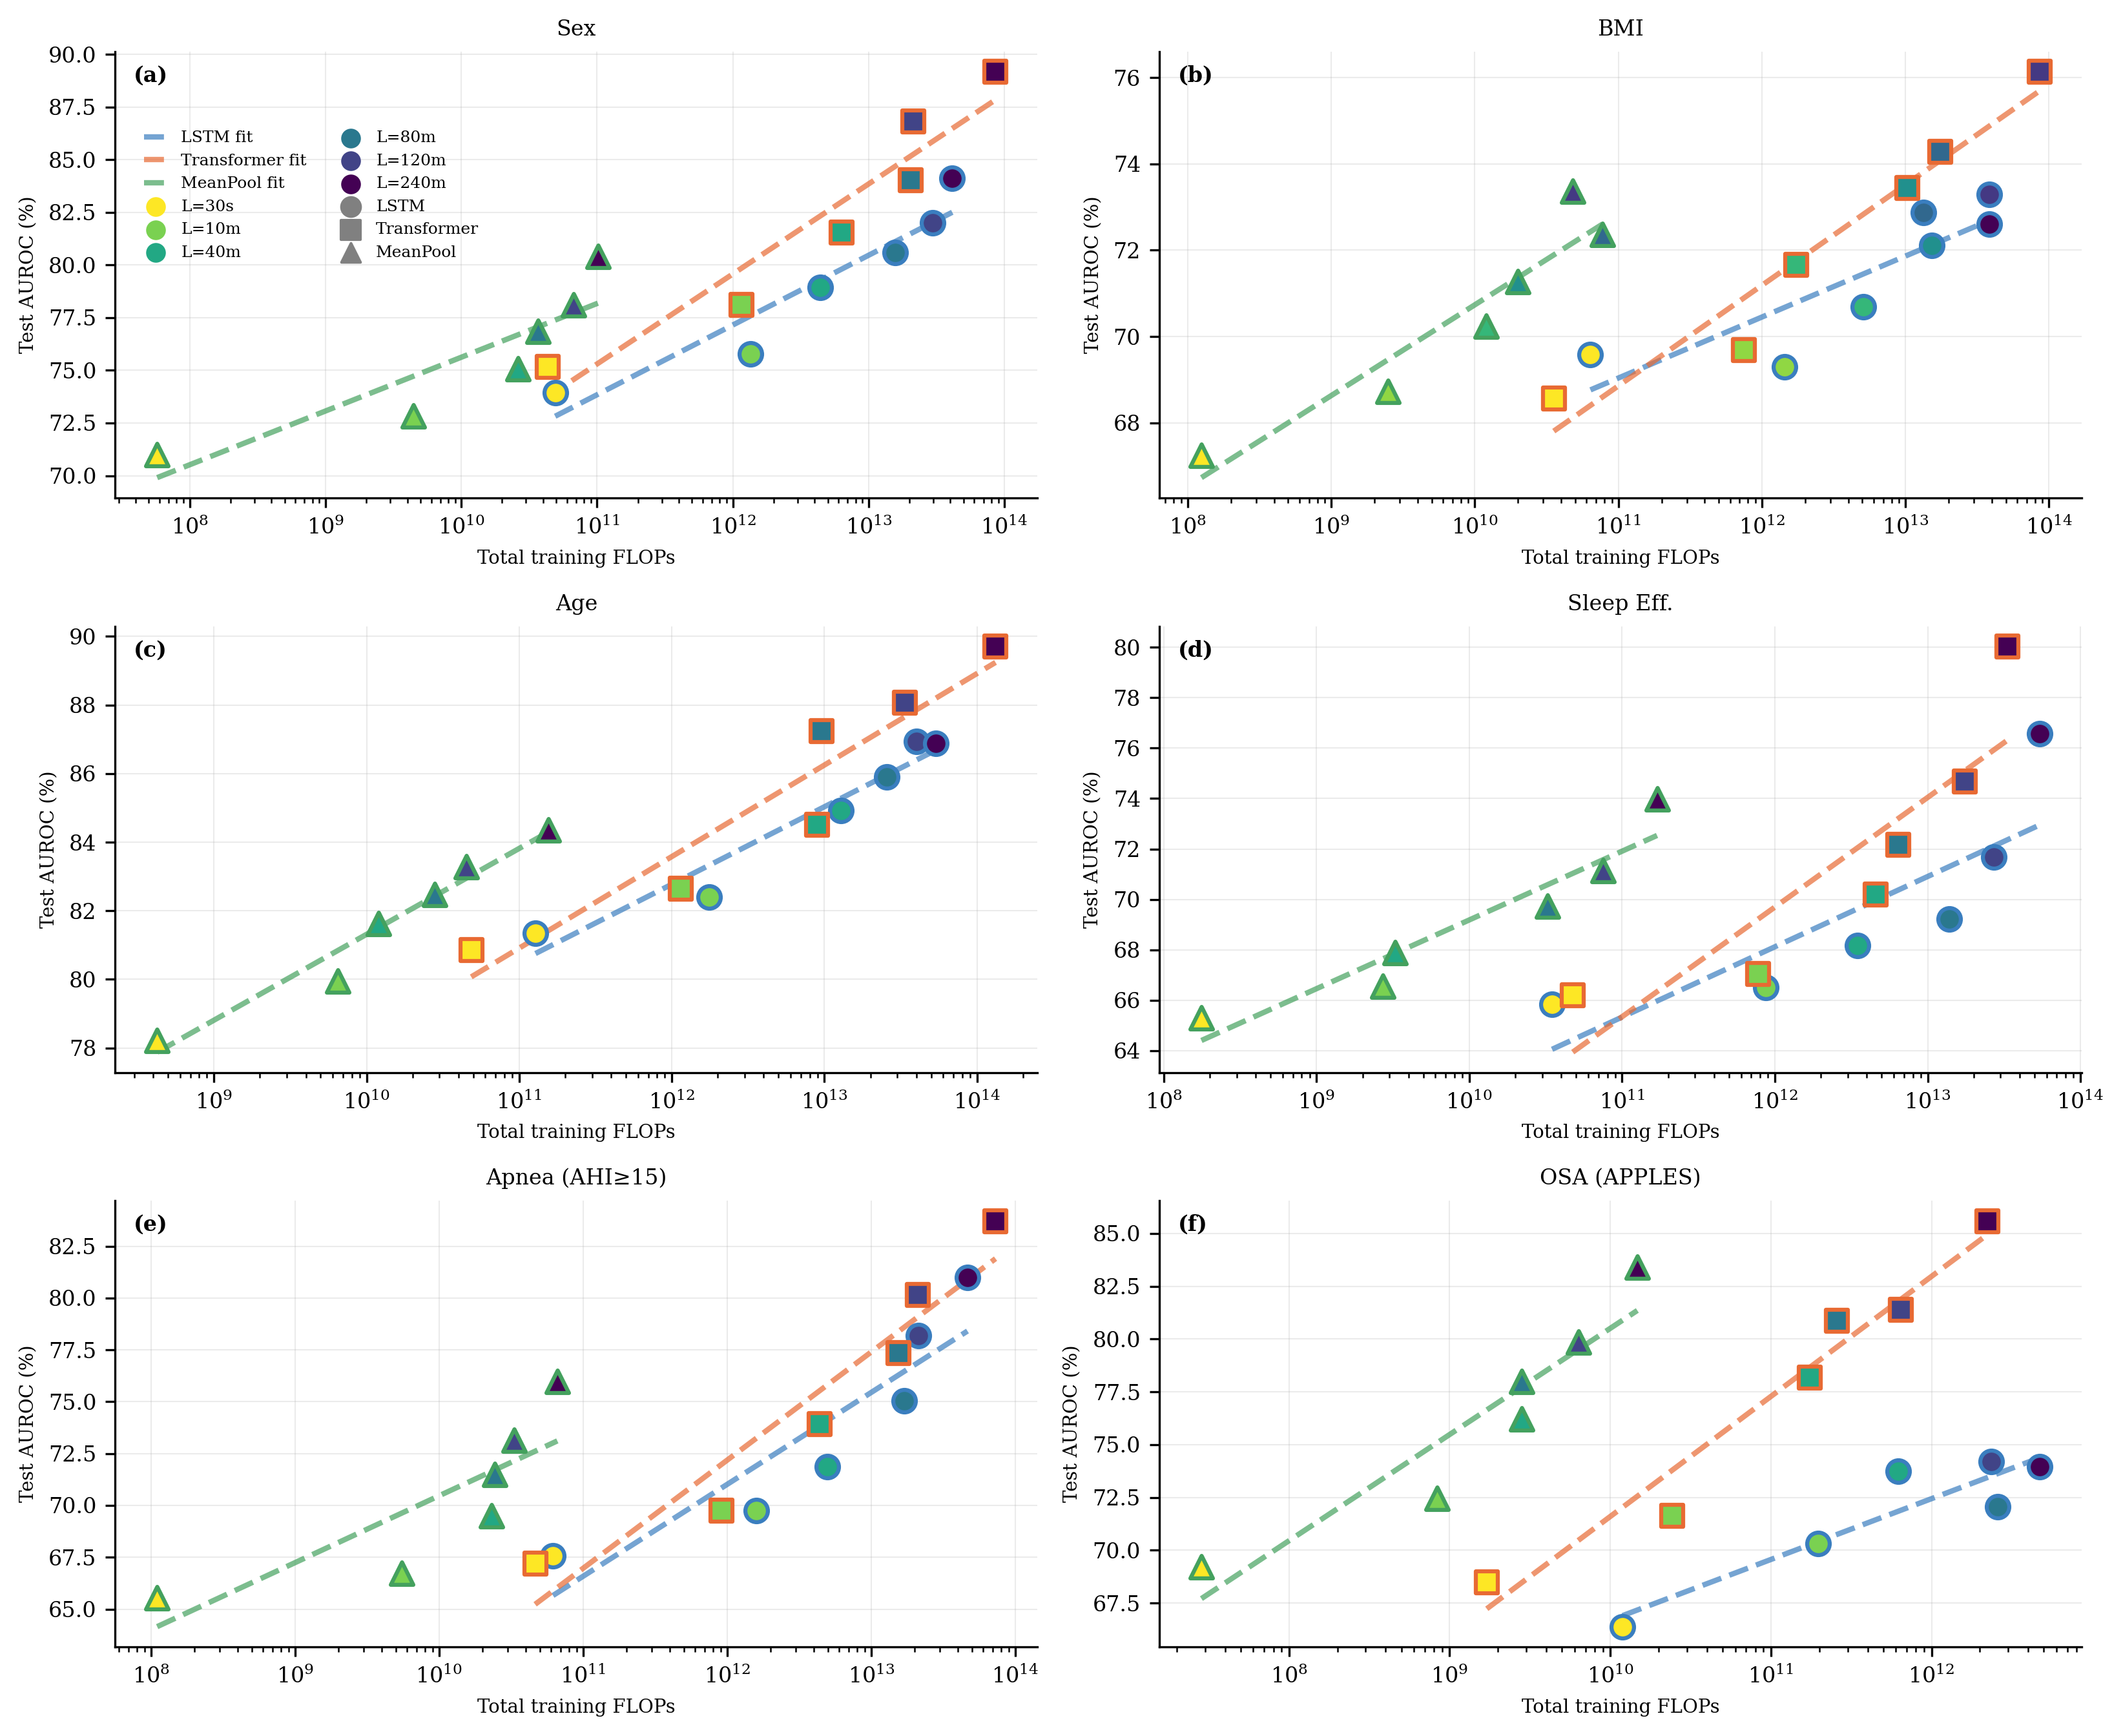

In [10]:
labels  = [chr(97 + i) for i in range(len(TASKS))]
n_last  = len(TASKS) % N_COLS or N_COLS
n_full  = len(TASKS) // N_COLS

mosaic = []
for row in range(n_full):
    rl = labels[row * N_COLS : (row + 1) * N_COLS]
    mosaic.append([l for l in rl for _ in range(2)])
if n_last < N_COLS:
    pad = N_COLS - n_last
    ll  = labels[n_full * N_COLS:]
    mosaic.append(["."] * pad + [l for l in ll for _ in range(2)] + ["."] * pad)

fig, axd = plt.subplot_mosaic(mosaic, figsize=(FIG_W, N_ROWS * ROW_H))

for i, (lbl, task) in enumerate(zip(labels, TASKS)):
    panels.compute_scaling_panel(axd[lbl], df_train, task, heads=HEADS, legend=False)
    axd[lbl].set_title(TASK_LABEL.get(task, task), fontsize=8)
    add_panel_label(axd[lbl], f"({lbl})")

# Single shared legend in panel (a) only.
# Fine-tune position with bbox_to_anchor=(x, y) in axes-fraction coords:
#   increase y to move up, decrease to move down.
_h, _l = axd["a"].get_legend_handles_labels()
axd["a"].legend(_h, _l, fontsize=FONT_ANNOT, frameon=False,
                handlelength=1.5, ncol=2,
                loc="lower right", bbox_to_anchor=(0.41, 0.5))

fig.tight_layout(h_pad=1.2, w_pad=1.0)
plt.show()

In [11]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "ext_fig2_compute_scaling")
import shutil
shutil.copy(FINAL_OUT / "ext_fig2_compute_scaling.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "ext_fig2_compute_scaling.pdf")
print("Saved + copied → npj_digital_medicine_submission/ext_fig2_compute_scaling.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig19_compute_scaling.pdf
Saved + copied → TBME_submission/sfig19_compute_scaling.pdf
